In [ ]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = housing.data
y = housing.target

In [ ]:
X.shape
y.shape

(20640,)

In [ ]:
import pandas as pd

print("feature names: ",housing.feature_names )

print("\n\n")

print("Data type of X:", type(X))
print("Shape of X:", X.shape)
print("Data type of y:", type(y))
print("Shape of y:", y.shape)

print("\n\n")

print("Number of missing values in X:\n", pd.DataFrame(X, columns=housing.feature_names).isnull().sum())
print("Number of missing values in y:", pd.Series(y).isnull().sum())

feature names:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']



Data type of X: <class 'numpy.ndarray'>
Shape of X: (20640, 8)
Data type of y: <class 'numpy.ndarray'>
Shape of y: (20640,)



Number of missing values in X:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Number of missing values in y: 0


## MinMax Scaler

In [ ]:
import numpy as np

# Min-Max Scaling 수행
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

print("Scaled X:", X_scaled)

Scaled X: [[0.53966842 0.78431373 0.0435123  ... 0.00149943 0.5674814  0.21115538]
 [0.53802706 0.39215686 0.03822395 ... 0.00114074 0.565356   0.21215139]
 [0.46602805 1.         0.05275646 ... 0.00169796 0.5642933  0.21015936]
 ...
 [0.08276438 0.31372549 0.03090386 ... 0.0013144  0.73219979 0.31175299]
 [0.09429525 0.33333333 0.03178269 ... 0.0011515  0.73219979 0.30179283]
 [0.13025338 0.29411765 0.03125246 ... 0.00154886 0.72582359 0.30976096]]


## 데이터 확인

In [ ]:
import numpy as np

# 가정: X와 y는 numpy 배열이고, 같은 수의 행을 가지고 있음
# X.shape[0] == y.shape[0] 이어야 함

# NaN 값을 찾기
nan_rows = np.isnan(X).any(axis=1) | np.isnan(y)

# NaN 값을 제거하기
X_clean = X[~nan_rows]
y_clean = y[~nan_rows]

print("Cleaned X:", X_clean)
print("Cleaned y:", y_clean)

# X_clean과 y_clean에 NaN 값이 있는지 확인
nan_in_X_clean = np.isnan(X_clean).any()
nan_in_y_clean = np.isnan(y_clean).any()

print("NaN in X_clean:", nan_in_X_clean)
print("NaN in y_clean:", nan_in_y_clean)

if not nan_in_X_clean and not nan_in_y_clean:
    print("There are no NaN values in X_clean and y_clean.")
else:
    if nan_in_X_clean:
        print("There are NaN values in X_clean.")
    if nan_in_y_clean:
        print("There are NaN values in y_clean.")

Cleaned X: [[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
Cleaned y: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
NaN in X_clean: False
NaN in y_clean: False
There are no NaN values in X_clean and y_clean.


In [ ]:
print(X_clean.shape,y_clean.shape)

(20640, 8) (20640,)


## 이상치 확인

In [ ]:
from scipy.stats import zscore

# X와 y의 z-score 계산
z_scores_X = zscore(X, axis=0)
z_scores_y = zscore(y, axis=0)

# z-score의 절대값이 2보다 큰 값을 찾기
outliers_X = (np.abs(z_scores_X) > 2).any(axis=1)
outliers_y = np.abs(z_scores_y) > 2

# X와 y에서 동일한 위치의 이상치를 찾기
outliers = outliers_X | outliers_y

# 이상치를 제거
X_clean = X[~outliers]
y_clean = y[~outliers]

print("Original size:", X.shape[0])
print("Size after removing outliers:", X_clean.shape[0])

Original size: 20640
Size after removing outliers: 17431


In [ ]:
print(X_clean.shape, y_clean.shape)

(17431, 8) (17431,)


## 데이터 분할

In [ ]:
import numpy as np

X = np.array(X_clean)
y = np.array(y_clean).reshape(-1, 1)

# 데이터를 훈련 세트, 검증 세트, 테스트 세트로 분할
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, X_temp = X[:train_size], X[train_size:]
y_train, y_temp = y[:train_size], y[train_size:]
X_val, X_test = X_temp[:val_size], X_temp[val_size:]
y_val, y_test = y_temp[:val_size], y_temp[val_size:]

print("훈련 세트 크기:", X_train.shape, y_train.shape)
print("검증 세트 크기:", X_val.shape, y_val.shape)
print("테스트 세트 크기:", X_test.shape, y_test.shape)


훈련 세트 크기: (12201, 8) (12201, 1)
검증 세트 크기: (2614, 8) (2614, 1)
테스트 세트 크기: (2616, 8) (2616, 1)


## 모델

In [ ]:
import numpy as np

class SimpleNN:
    def __init__(self, layer_sizes, learning_rate=0.01, initialization='he'):
        # 매개변수 및 하이퍼파라미터 초기화
        self.params = {}  # 가중치와 편향을 저장할 딕셔너리
        self.learning_rate = learning_rate  # 경사하강법의 학습률

        print("다음 구조를 가진 신경망을 구축합니다:")
        # 입력층
        print(f"입력층: {layer_sizes[0]} 뉴런")

        # 각 층의 가중치와 편향 초기화
        for i in range(1, len(layer_sizes)):
            # 가중치 초기화
            if initialization == 'he':
                self.params['W' + str(i)] = np.random.randn(layer_sizes[i-1], layer_sizes[i]) * np.sqrt(2. / layer_sizes[i-1])
            elif initialization == 'xavier':
                self.params['W' + str(i)] = np.random.randn(layer_sizes[i-1], layer_sizes[i]) * np.sqrt(1. / layer_sizes[i-1])
            else:
                raise ValueError("유효하지 않은 초기화 방법입니다. 'he' 또는 'xavier'를 선택하세요.")

            # 편향을 0으로 초기화
            self.params['b' + str(i)] = np.zeros((1, layer_sizes[i]))

            # 층 정보 출력
            print(f"은닉층 {i} (해당되는 경우): {layer_sizes[i-1]} 뉴런 -> {layer_sizes[i]} 뉴런")

        # 출력층
        print(f"출력층: {layer_sizes[-1]} 뉴런")


    def forward(self, X):
        # 신경망을 통한 순방향 전파
        activations = {'A0': X}  # 활성화 값을 저장할 딕셔너리
        L = len(self.params) // 2  # 총 층의 개수
        for i in range(1, L + 1):
            # 선형 변환
            Z = np.dot(activations['A' + str(i-1)], self.params['W' + str(i)]) + self.params['b' + str(i)]
            # 출력층이 아니면 ReLU 활성화 함수 적용
            if i < L:
                # A = self.leaky_ReLU(Z)
                A = self.ReLU(Z)
            else:
                A = Z  # 출력층에는 선형 활성화 함수 적용
            activations['Z' + str(i)] = Z
            activations['A' + str(i)] = A
        return activations



    def backward(self, X, y_true):
        # 신경망을 통한 역방향 전파하여 그래디언트 계산
        activations = self.forward(X)  # 순방향 전파를 통해 활성화 값 얻기
        gradients = {}  # 그래디언트를 저장할 딕셔너리
        m = y_true.shape[0]  # 샘플의 개수

        # 출력층의 그래디언트 계산
        dZ = 2 * (activations['A' + str(len(self.params)//2)] - y_true) / m
        gradients['dW' + str(len(self.params)//2)] = np.dot(activations['A' + str(len(self.params)//2 - 1)].T, dZ)
        gradients['db' + str(len(self.params)//2)] = np.sum(dZ, axis=0, keepdims=True) /m

        # 은닉층을 통한 역방향 전파
        for i in range(len(self.params)//2 - 1, 0, -1):
            dA = np.dot(dZ, self.params['W' + str(i+1)].T)
            # dZ = dA * self.leaky_ReLU_derivative(activations['Z' + str(i)])
            dZ = dA * self.ReLU_derivative(activations['Z' + str(i)])
            gradients['dW' + str(i)] = np.dot(activations['A' + str(i-1)].T, dZ)
            gradients['db' + str(i)] = np.sum(dZ, axis=0, keepdims=True) / m

        # 확률적 경사 하강법을 사용하여 매개변수 업데이트
        self.sgd(gradients)


    def sgd(self, gradients, max_grad=5):
        # 확률적 경사 하강법을 사용하여 매개변수 업데이트
        for i in range(1, len(self.params)//2 + 1):
            # 그래디언트 클리핑
            gradients['dW' + str(i)] = np.clip(gradients['dW' + str(i)], -max_grad, max_grad)
            gradients['db' + str(i)] = np.clip(gradients['db' + str(i)], -max_grad, max_grad)
            # 매개변수 업데이트
            self.params['W' + str(i)] -= self.learning_rate * gradients['dW' + str(i)]
            self.params['b' + str(i)] -= self.learning_rate * gradients['db' + str(i)]



    def RMSE(self, y_pred, y_true):
        # 평균 제곱근 오차(Root Mean Squared Error) 손실 함수
        mse = ((y_pred - y_true) ** 2).mean()
        return np.sqrt(mse)

    def MSE(self, y_pred, y_true):
        # 평균 제곱근 오차(Root Mean Squared Error) 손실 함수
        return ((y_pred - y_true) ** 2).mean()

    ## 활성화 함수

    def sigmoid(self, z):
        # z 값이 100보다 크면 오버플로를 방지하기 위해 1을 반환
        z = np.clip(z, -100, 100)
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        # 시그모이드 함수의 도함수
        sig = self.sigmoid(z)
        return sig * (1 - sig)

    def ReLU(self, Z):
        # Rectified linear unit 활성화 함수
        return np.maximum(0, Z)

    def ReLU_derivative(self, Z):
        # ReLU 활성화 함수의 도함수
        return (Z > 0).astype(float)

    def leaky_ReLU(self, Z, alpha=0.01):
      # Leaky ReLU 활성화 함수
      return np.maximum(alpha * Z, Z)

    def leaky_ReLU_derivative(self, Z, alpha=0.01):
        # Leaky ReLU 활성화 함수의 도함수
        return (Z > 0) + alpha * (Z <= 0)



## 모델 훈련

In [ ]:
import numpy as np

# 앞서 정의한 SimpleNN 클래스를 사용하여 인공 신경망 인스턴스 생성
# 입력층 8개, 은닉층 4개 (각각 16, 16, 8, 8개 뉴런), 출력층 1개
nn = SimpleNN(layer_sizes=[8, 64, 64, 32, 16, 8, 4, 1], learning_rate=0.0001, initialization='he')

# 학습을 위한 설정
# 에포크: 전체 데이터 세트에 대한 학습 횟수
epochs = 1000
# patience: 성능 향상이 없을 때 기다리는 에포크 수
patience = 30
# 미니배치 크기: 각 학습 단계에서 사용되는 데이터 샘플 수
batch_size = 64

# Early stopping을 위한 변수 초기화
# 최고의 손실 값을 저장
best_loss = np.inf
# 성능이 향상되지 않는 에포크 수를 세기 위한 변수
no_improvement_count = 0
# 가장 좋은 가중치를 저장하기 위한 변수
best_weights = None

# 검증 데이터의 손실을 모니터링하기 위한 변수 초기화
best_val_loss = np.inf

# 학습 시작
for epoch in range(epochs):
    # 데이터 세트를 미니배치로 나누기
    num_batches = int(np.ceil(X_train.shape[0] / batch_size))
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)  # 데이터 세트를 무작위로 섞음

    # 각 미니배치에 대한 학습
    for batch in range(num_batches):
        start = batch * batch_size
        end = min(start + batch_size, X_train.shape[0])
        X_batch = X_train[indices[start:end]]
        y_batch = y_train[indices[start:end]]

        # 순방향 계산
        activations = nn.forward(X_batch)

        # 손실 계산 (미니배치에 대해서)
        loss_train = nn.MSE(activations['A' + str(len(nn.params)//2)], y_batch)

        # 역방향 계산 및 파라미터 업데이트
        nn.backward(X_batch, y_batch)

    # 검증 데이터에 대한 순방향 계산
    activations_val = nn.forward(X_val)

    # 검증 데이터에 대한 손실 계산
    loss_val = nn.MSE(activations_val['A' + str(len(nn.params)//2)], y_val)

    # Early stopping 검사
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        best_weights = nn.params.copy()
        no_improvement_count = 0
    else:
        no_improvement_count += 1
        if no_improvement_count >= patience:
            print(f"조기 종료 - 에포크 {epoch}에서 학습 중단!")
            nn.params = best_weights  # 최고의 가중치로 복원
            break

    # 일정 에포크마다 학습 상황 출력
    if epoch % 50 == 0:
        print(f'에포크 {epoch}, 훈련 손실: {loss_train}, 검증 손실: {loss_val}')

# 학습 완료 후 테스트 데이터에 대한 예측 수행
y_pred = nn.forward(X_test)['A' + str(len(nn.params)//2)]

# 결과 출력
# print('학습된 가중치 및 편향:', nn.params)
print('예측값:', y_pred)

다음 구조를 가진 신경망을 구축합니다:
입력층: 8 뉴런
은닉층 1 (해당되는 경우): 8 뉴런 -> 64 뉴런
은닉층 2 (해당되는 경우): 64 뉴런 -> 64 뉴런
은닉층 3 (해당되는 경우): 64 뉴런 -> 32 뉴런
은닉층 4 (해당되는 경우): 32 뉴런 -> 16 뉴런
은닉층 5 (해당되는 경우): 16 뉴런 -> 8 뉴런
은닉층 6 (해당되는 경우): 8 뉴런 -> 4 뉴런
은닉층 7 (해당되는 경우): 4 뉴런 -> 1 뉴런
출력층: 1 뉴런
에포크 0, 훈련 손실: 388.1271623370482, 검증 손실: 166.52495868420192
에포크 50, 훈련 손실: 1.0348741615720545, 검증 손실: 1.5500234928737768
조기 종료 - 에포크 97에서 학습 중단!
예측값: [[1.93037511]
 [1.882885  ]
 [1.94638452]
 ...
 [1.84343658]
 [1.85101039]
 [1.88103944]]


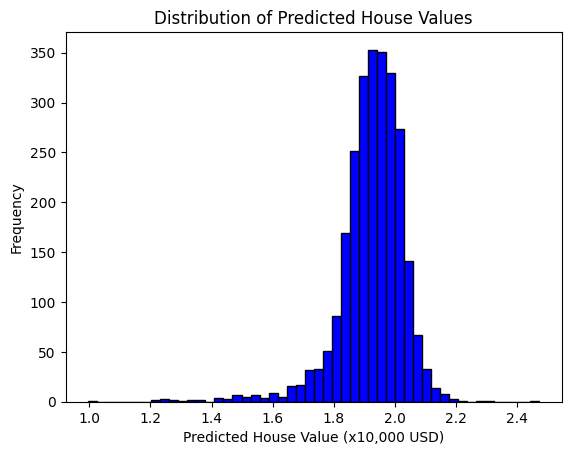

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 예측값 역변환
def inverse_transform(scaled_data, min_value, max_value):
    return scaled_data * (max_value - min_value) + min_value

# # 역변환 수행
# y_transfrom = inverse_transform(y_pred, y_min, y_max)
# y_test_transfrom  = inverse_transform(y_test, y_min, y_max)

# 히스토그램을 그립니다.
plt.hist(y_pred, bins=50, color='blue', edgecolor='black')

# 그래프의 제목과 레이블을 추가합니다.
plt.title('Distribution of Predicted House Values')
plt.xlabel('Predicted House Value (x10,000 USD)')
plt.ylabel('Frequency')

# 그래프를 보여줍니다.
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import scipy.stats as stats
# 평가 지표 계산
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 0.780143629258416
Mean Absolute Error: 0.7298888308046855
R^2 Score: 0.0708859755970409


In [ ]:
for i in range(10):
  print(i+1, y_pred[i+1], y_test[i+1])

1 [1.882885] [1.726]
2 [1.94638452] [1.344]
3 [1.96967236] [1.801]
4 [1.92750727] [1.422]
5 [1.95236718] [2.231]
6 [2.0206159] [2.493]
7 [1.95743928] [2.072]
8 [1.94855424] [1.527]
9 [1.98538813] [1.838]
10 [1.9551281] [2.906]


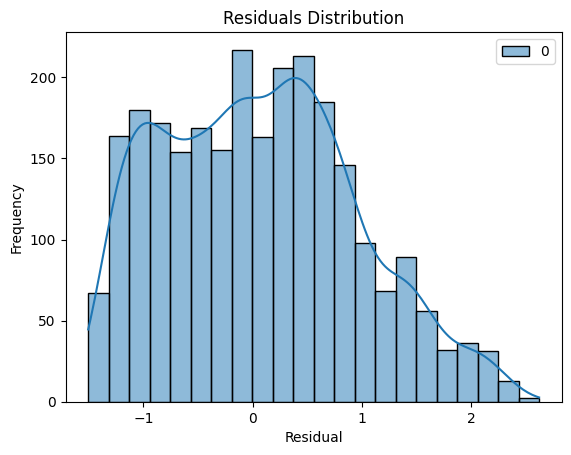

In [ ]:
# 잔차 계산
residuals = y_test - y_pred

# 잔차 분포 플롯
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

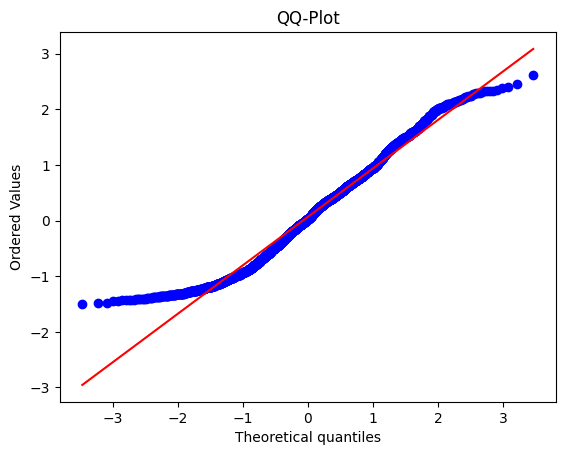

In [ ]:
# 잔차 계산
residuals = y_test - y_pred

# 1차원 배열로 변환
residuals = residuals.ravel()

# QQ-plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot')
plt.show()

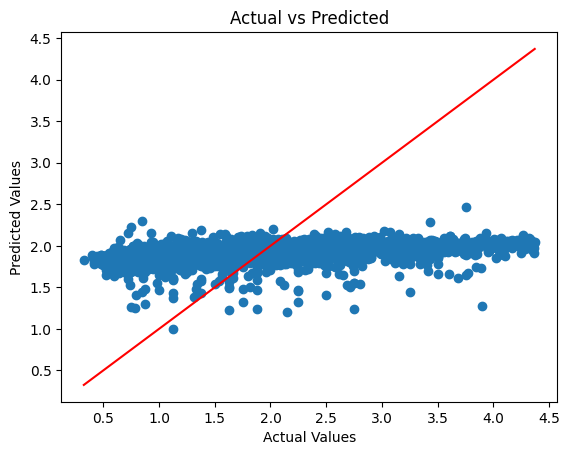

In [ ]:
# 실제 값 vs 예측 값
plt.scatter(y_test, y_pred)
plt.title('Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 대각선
plt.show()